Numeric-only shape: (6378, 7)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,23,84,7,73,0,3,67
1,19,64,8,59,2,4,61
2,24,98,7,91,2,4,74
3,29,89,8,98,1,4,71
4,19,92,6,65,3,4,70
5,19,88,8,89,3,3,71
6,29,84,7,68,1,2,67
7,25,78,6,50,1,2,66
8,17,94,6,80,0,1,69
9,23,98,8,71,0,5,72



DBSCAN cluster counts (label -> count):
{np.int64(-1): np.int64(55), np.int64(0): np.int64(6323)}

# clusters found (excluding noise): 1
# noise points: 55


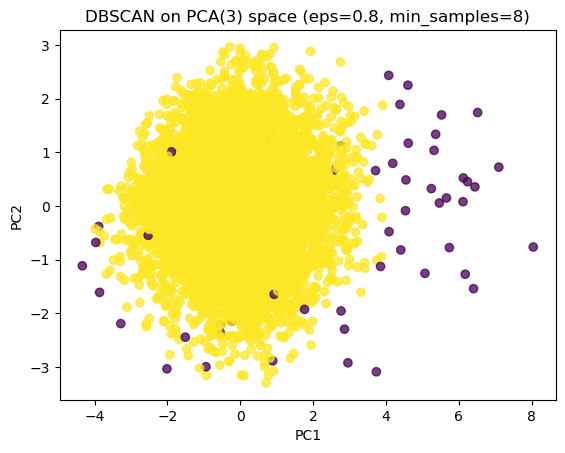

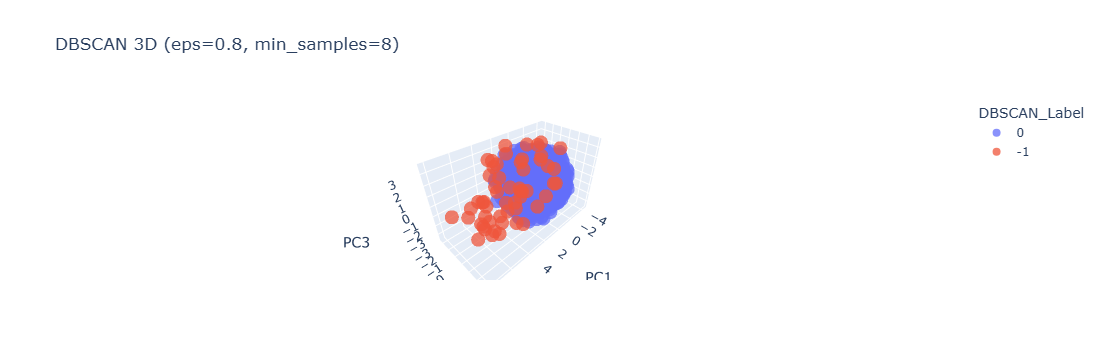


DBSCAN silhouette not computed (need >=2 clusters among non-noise points).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# -----------------------------
# 1) Load + clean numeric data (same approach as your other sections)
# -----------------------------
path = (r"C:\Users\User\Machine\Jupyter file\dataset1_raw.csv")
raw_df = pd.read_csv(path).dropna()

LABEL_COLS = []  # if your dataset has a label column, put it here
DROP_COLS = ["id", "gender", "occupation_type"]  # qualitative columns to remove

df_work = raw_df.copy()

# drop labels if present
label_present = [c for c in LABEL_COLS if c in df_work.columns]
if label_present:
    df_work = df_work.drop(columns=label_present)

# drop known non-quantitative columns
drop_present = [c for c in DROP_COLS if c in df_work.columns]
df_work = df_work.drop(columns=drop_present)

# keep numeric only (guarantees quantitative)
df_numeric = df_work.select_dtypes(include=[np.number]).copy()

print("Numeric-only shape:", df_numeric.shape)
display(df_numeric.head(10))

SAVED_DATASET_PATH = (r"C:\Users\User\Machine\Jupyter file\dataset1_dbscan_clean.csv")
df_numeric.to_csv(SAVED_DATASET_PATH, index=False)

# -----------------------------
# 2) Normalize
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# -----------------------------
# 3) PCA to 3 components (so it’s directly comparable to your KMeans/Hierarchical runs)
# -----------------------------
pca3 = PCA(n_components=3, random_state=42)
Z3 = pca3.fit_transform(X_scaled)

# -----------------------------
# 4) DBSCAN
#    eps and min_samples matter a lot — start with these and tune.
# -----------------------------
eps = 0.8          # try 0.3–2.0 depending on your dataset scale and PCA space
min_samples = 8    # try 4–20 depending on dataset size

db = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = db.fit_predict(Z3)

# DBSCAN labels: -1 means "noise"
unique, counts = np.unique(db_labels, return_counts=True)
print("\nDBSCAN cluster counts (label -> count):")
print(dict(zip(unique, counts)))

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)
print(f"\n# clusters found (excluding noise): {n_clusters}")
print(f"# noise points: {n_noise}")

# -----------------------------
# 5) Visualization (PC1 vs PC2)
# -----------------------------
plt.figure()
plt.scatter(Z3[:, 0], Z3[:, 1], c=db_labels, alpha=0.75)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"DBSCAN on PCA(3) space (eps={eps}, min_samples={min_samples})")
plt.show()

# Optional: 3D visualization (PC1, PC2, PC3)
try:
    import plotly.express as px
    pca_df = pd.DataFrame(Z3, columns=["PC1", "PC2", "PC3"])
    pca_df["DBSCAN_Label"] = db_labels.astype(str)

    fig = px.scatter_3d(
        pca_df, x="PC1", y="PC2", z="PC3",
        color="DBSCAN_Label",
        opacity=0.75,
        title=f"DBSCAN 3D (eps={eps}, min_samples={min_samples})"
    )
    fig.show()
except Exception as e:
    print("Plotly not available or failed:", e)

# -----------------------------
# 6) Silhouette score (only valid if DBSCAN forms >=2 clusters and not all noise)
# -----------------------------
valid_mask = db_labels != -1
valid_labels = db_labels[valid_mask]

# silhouette requires at least 2 clusters among non-noise points
if len(set(valid_labels)) >= 2 and np.sum(valid_mask) > len(set(valid_labels)):
    sil = silhouette_score(Z3[valid_mask], valid_labels)
    print(f"\nDBSCAN silhouette (excluding noise): {sil:.4f}")
else:
    print("\nDBSCAN silhouette not computed (need >=2 clusters among non-noise points).")